##**TASK 4**

###Import statements

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

###Data Load

In [ ]:
df = pd.read_csv("advertising.csv")
print(df.head())
print(df.shape)

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
(200, 4)


###Correlation Heatmap

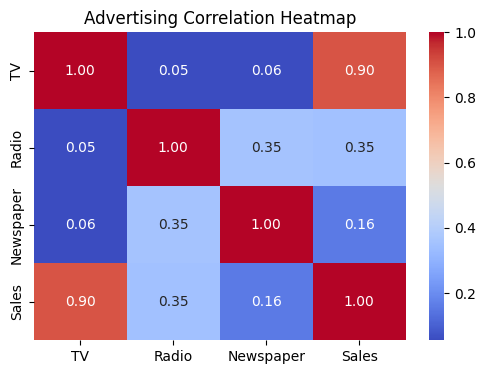

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Advertising Correlation Heatmap")
plt.show()

###Model training and prediction

In [ ]:
X = df.drop("Sales", axis=1)
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

###Accuracy Analysis

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\nMAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


MAE  : 1.27
RMSE : 1.71
R²   : 0.91


###Actual vs Predicted Sales Plot

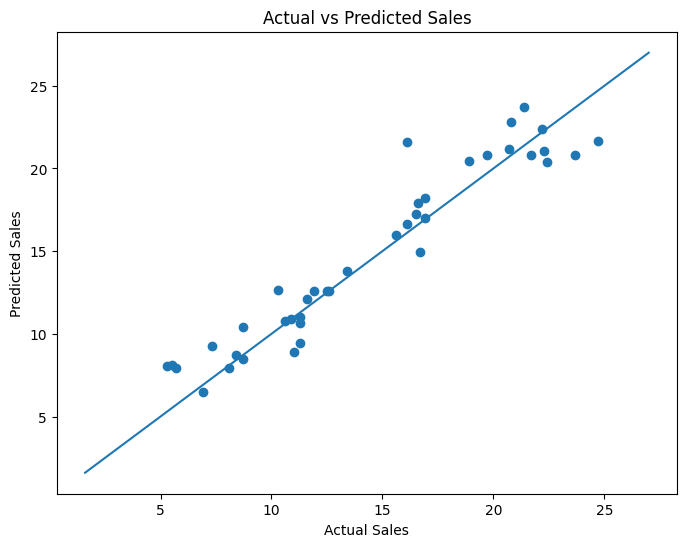

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()]
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

###User Prediction

In [ ]:
print("\nEnter Advertising Budget")
tv = float(input("TV Advertising Budget: "))
radio = float(input("Radio Advertising Budget: "))
newspaper = float(input("Newspaper Advertising Budget: "))
new_data = pd.DataFrame({
    "TV": [tv],
    "Radio": [radio],
    "Newspaper": [newspaper]
})
prediction = model.predict(new_data)
print(f"\nPredicted Sales: {prediction[0]:.2f}")


Enter Advertising Budget
TV Advertising Budget: 230.1
Radio Advertising Budget: 37.8
Newspaper Advertising Budget: 69.2

Predicted Sales: 21.37
